# Football Betting Market Analysis

This notebook is the main working notebook for the closing-odds pipeline.

It is designed to work with the existing Python modules in the project, so the notebook stays clean while the reusable logic lives in `.py` files.

## Pipeline covered here

1. Load project modules
2. Preprocess raw closing odds
3. Build engineered features
4. Save processed data
5. Create a time-based train-test split
6. Run baseline backtests
7. Inspect evaluation tables
8. Prepare for probability calibration


## Recommended project structure

```text
project_root/
│
├── data/
│   ├── raw/
│   └── processed/
│
├── results/
│   └── closing_backtest/
│
├── src/
│   └── betproj/
│       ├── data_loader.py
│       ├── preprocess_closing.py
│       ├── features_closing.py
│       └── backtest.py
│
├── scripts/
│   ├── build_closing_data.py
│   └── run_closing_backtest.py
│
└── notebooks/
    └── 01_closing_pipeline.ipynb
```

The notebook should orchestrate the workflow, while the real logic remains in the package modules.

In [1]:
from pathlib import Path
import sys

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

sys.path.append(str(PROJECT_ROOT / "src"))

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results" / "closing_backtest"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = c:\pl-pred\EPL-prediction


## Import project modules

These imports connect the notebook to the modular backend.

In [2]:
from betproj.data_loader import load_closing_odds
from betproj.preprocess_closing import preprocess_closing_odds
from betproj.features_closing import build_closing_features
from betproj.backtest import select_bets, threshold_grid_backtest, evaluation_tables


## Step 1 — Load raw closing odds

This is the raw historical closing-odds dataset.

In [3]:
df_raw = load_closing_odds()
print(df_raw.shape)
df_raw.head()

(479440, 19)


,match_id,league,match_date,home_team,home_score,away_team,away_score,avg_odds_home_win,avg_odds_draw,avg_odds_away_win,max_odds_home_win,max_odds_draw,max_odds_away_win,top_bookie_home_win,top_bookie_draw,top_bookie_away_win,n_odds_home_win,n_odds_draw,n_odds_away_win
0,170088,England: Premier League,2005-01-01,Liverpool,0,Chelsea,1,2.9944,3.1944,2.2256,3.20,3.25,2.29,Paddy Power,Sportingbet,Expekt,9,9,9
1,170089,England: Premier League,2005-01-01,Fulham,3,Crystal Palace,1,1.9456,3.2333,3.6722,2.04,3.30,4.15,Pinnacle Sports,bet-at-home,Expekt,9,9,9
2,170090,England: Premier League,2005-01-01,Aston Villa,1,Blackburn,0,1.8522,3.2611,4.0144,2.00,3.40,4.50,Pinnacle Sports,Paddy Power,Sportingbet,9,9,9
3,170091,England: Premier League,2005-01-01,Bolton,1,West Brom,1,1.6122,3.4133,5.4722,1.67,3.57,6.27,Coral,Pinnacle Sports,Pinnacle Sports,9,9,9
4,170092,England: Premier League,2005-01-01,Charlton,1,Arsenal,3,5.9878,3.4778,1.5567,7.00,3.60,1.62,Expekt,Paddy Power,bet365,9,9,9


## Step 2 — Preprocess

This parses the match date and adds the categorical match result:

- `H` = home win
- `D` = draw
- `A` = away win


In [4]:
df_pre = preprocess_closing_odds()
print(df_pre.shape)
df_pre[['match_id', 'match_date', 'home_team', 'away_team', 'home_score', 'away_score', 'result']].head()

(479440, 20)


,match_id,match_date,home_team,away_team,home_score,away_score,result
0,170088,2005-01-01,Liverpool,Chelsea,0,1,A
1,170089,2005-01-01,Fulham,Crystal Palace,3,1,H
2,170090,2005-01-01,Aston Villa,Blackburn,1,0,H
3,170091,2005-01-01,Bolton,West Brom,1,1,D
4,170092,2005-01-01,Charlton,Arsenal,1,3,A


## Step 3 — Feature engineering

This builds the core closing features:

- normalized implied probabilities
- expected values
- profit columns
- value-gap features


In [5]:
df = build_closing_features(df_pre)
print(df.shape)
df.head()

(479440, 35)


,match_id,league,match_date,home_team,home_score,away_team,away_score,avg_odds_home_win,avg_odds_draw,avg_odds_away_win,...,gap_away,rel_gap_home,rel_gap_draw,rel_gap_away,ev_home,ev_draw,ev_away,profit_home,profit_draw,profit_away
0,170088,England: Premier League,2005-01-01,Liverpool,0,Chelsea,1,2.9944,3.1944,2.2256,...,0.0644,0.068662,0.017405,0.028936,-0.025230,-0.071983,-0.061465,-1.00,-1.00,1.29
1,170089,England: Premier League,2005-01-01,Fulham,3,Crystal Palace,1,1.9456,3.2333,3.6722,...,0.4778,0.048520,0.020629,0.130113,-0.042953,-0.068410,0.031522,1.04,-1.00,-1.00
2,170090,England: Premier League,2005-01-01,Aston Villa,1,Blackburn,0,1.8522,3.2611,4.0144,...,0.4856,0.079797,0.042593,0.120965,-0.014466,-0.048422,0.023108,1.00,-1.00,-1.00
3,170091,England: Premier League,2005-01-01,Bolton,1,West Brom,1,1.6122,3.4133,5.4722,...,0.7978,0.035852,0.045909,0.145791,-0.054866,-0.045690,0.045446,-1.00,2.57,-1.00
4,170092,England: Premier League,2005-01-01,Charlton,1,Arsenal,3,5.9878,3.4778,1.5567,...,0.0633,0.169044,0.035137,0.040663,0.065742,-0.056332,-0.051294,-1.00,-1.00,0.62


## Step 4 — Save processed features

This keeps the pipeline reproducible and avoids recomputing features each time.

In [6]:
processed_path = DATA_PROCESSED / 'closing_features.parquet'
df.to_parquet(processed_path, index=False)
processed_path

WindowsPath('c:/pl-pred/EPL-prediction/data/processed/closing_features.parquet')

## Step 5 — Time-based train-test split

For a betting project, the split must be chronological, not random.

This avoids look-ahead bias.

Default split used here:

- train: up to 2012
- test: 2013 onward


In [7]:
import pandas as pd 
df['match_date'] = pd.to_datetime(df['match_date'])
df = df.sort_values('match_date').reset_index(drop=True)
df['year'] = df['match_date'].dt.year

train = df[df['year'] <= 2012].copy()
test = df[df['year'] >= 2013].copy()

print('Train shape:', train.shape)
print('Test shape:', test.shape)
print('Train years:', train['year'].min(), '-', train['year'].max())
print('Test years:', test['year'].min(), '-', test['year'].max())

Train shape: (305545, 36)
Test shape: (173895, 36)
Train years: 2005 - 2012
Test years: 2013 - 2015


In [8]:
train_path = DATA_PROCESSED / 'train_closing.parquet'
test_path = DATA_PROCESSED / 'test_closing.parquet'

train.to_parquet(train_path, index=False)
test.to_parquet(test_path, index=False)

train_path, test_path

(WindowsPath('c:/pl-pred/EPL-prediction/data/processed/train_closing.parquet'),
 WindowsPath('c:/pl-pred/EPL-prediction/data/processed/test_closing.parquet'))

## Step 6 — Training-set baseline backtest

These are only development results.

Use the training set to explore thresholds and filters, then lock them before evaluating on the test set.

In [10]:
train_bets = select_bets(
    df=train,
    ev_threshold=0.09,
    mode='best_per_match',
    min_n_odds=10,
    max_odds_allowed=4,
)

train_summary = evaluation_tables(train_bets)['summary']
train_summary

C:\pl-pred\EPL-prediction\src\betproj\backtest.py:154: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bets.groupby(group_col, dropna=False)


,n_bets,hit_rate,total_profit,total_staked,roi,avg_ev,avg_odds
0,5340,0.374345,811.33,5340.0,0.151934,0.162539,3.244067


## Threshold grid on training set

This is where you tune the EV threshold using only training data.

In [12]:
thresholds = [0.00, 0.01, 0.02, 0.03, 0.05, 0.08, 0.10]
train_grid = threshold_grid_backtest(
    df=train,
    thresholds=thresholds,
    mode='best_per_match',
    min_n_odds=10,
    max_odds_allowed=4,
)

train_grid

,n_bets,hit_rate,total_profit,total_staked,roi,avg_ev,avg_odds,ev_threshold,mode,min_n_odds,max_odds_allowed,min_odds_allowed
0,74595.0,0.335639,-75.82,74595.0,-0.001016,0.038310,3.160600,0.00,best_per_match,10,4,None
1,58345.0,0.331802,9.62,58345.0,0.000165,0.047611,3.187374,0.01,best_per_match,10,4,None
2,44474.0,0.330283,207.68,44474.0,0.004670,0.057838,3.208215,0.02,best_per_match,10,4,None
3,33230.0,0.331718,495.54,33230.0,0.014912,0.069031,3.221776,0.03,best_per_match,10,4,None
4,17902.0,0.338286,790.76,17902.0,0.044172,0.094707,3.250093,0.05,best_per_match,10,4,None
5,7168.0,0.358817,792.58,7168.0,0.110572,0.142715,3.260590,0.08,best_per_match,10,4,None
6,4015.0,0.382565,653.53,4015.0,0.162772,0.184915,3.216615,0.10,best_per_match,10,4,None


## Step 7 — Freeze parameters and evaluate on test set

After selecting a threshold on the training set, apply exactly the same parameters to the test set.

In [14]:
chosen_threshold = 0.08
chosen_max_odds = 4

test_bets = select_bets(
    df=test,
    ev_threshold=chosen_threshold,
    mode='best_per_match',
    min_n_odds=10,
    max_odds_allowed=chosen_max_odds,
)

test_tables = evaluation_tables(test_bets)
test_tables['summary']

C:\pl-pred\EPL-prediction\src\betproj\backtest.py:154: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bets.groupby(group_col, dropna=False)


,n_bets,hit_rate,total_profit,total_staked,roi,avg_ev,avg_odds
0,3169,0.353739,252.35,3169.0,0.079631,0.129857,3.242963


In [30]:
test_tables['by_year'].head(20)

,year,n_bets,hit_rate,total_profit,total_staked,avg_ev,avg_odds,roi
0,2014,1503,0.307385,208.48,1503.0,0.151880,3.967512,0.138709
1,2015,698,0.319484,93.62,698.0,0.170334,3.835516,0.134126
2,2013,1655,0.281571,79.39,1655.0,0.150085,4.024363,0.047970


In [33]:
test_tables['by_league'].head(20)

,league,n_bets,hit_rate,total_profit,total_staked,avg_ev,avg_odds,roi
0,Uzbekistan: Professional Football League,1,1.0,4.00,1.0,0.134824,5.000000,4.000000
1,Tunisia: Tunisia Cup,1,1.0,4.00,1.0,0.973931,5.000000,4.000000
2,Finland: Kakkonen West,1,1.0,4.00,1.0,0.111565,5.000000,4.000000
3,Iceland: Icelandic Cup,1,1.0,3.80,1.0,1.958296,4.800000,3.800000
4,Czech Republic: Pohar Ceske posty,1,1.0,3.80,1.0,0.158177,4.800000,3.800000
5,Moldova: Moldovan Cup,1,1.0,3.70,1.0,0.330386,4.700000,3.700000
6,Portugal: Super Cup,1,1.0,3.59,1.0,0.122329,4.590000,3.590000
7,Brazil: Campeonato Catarinense,1,1.0,3.50,1.0,0.121176,4.500000,3.500000
8,Philippines: UFL,1,1.0,3.50,1.0,0.135641,4.500000,3.500000
9,Finland: Kakkonen Play Offs,1,1.0,3.31,1.0,0.150706,4.310000,3.310000


In [34]:
test_tables['by_n_odds_bin'].head(20)

,n_odds_bin,n_bets,hit_rate,total_profit,total_staked,avg_ev,avg_odds,roi
0,6-10,64,0.500000,45.56,64.0,0.207732,3.540938,0.711875
1,11-15,420,0.392857,124.58,420.0,0.190056,3.591286,0.296619
2,16-20,525,0.333333,73.93,525.0,0.178294,3.769981,0.140819
3,21-25,1009,0.285431,80.03,1009.0,0.151576,4.004054,0.079316
4,26-32,1838,0.267138,57.39,1838.0,0.139225,4.105762,0.031224
5,1-5,0,NaN,0.00,0.0,NaN,NaN,NaN
6,33+,0,NaN,0.00,0.0,NaN,NaN,NaN


## Further diagnosis with many metrics






# A lot of diagnosis (can be found in src: diagnosis.py) can give useful metrics:

In [15]:
from betproj.diagnostics import (
    odds_band_test,
    ev_band_test,
    n_odds_band_test,
    bookmaker_test,
    league_test,
    calibration_table,
    yearly_test,
    cumulative_profit_plot,
    cumulative_profit_by_time_plot,
    drawdown_analysis,
    stability_by_chunk_test,
    outcome_mix_test,
    threshold_sweep_test,
    randomized_ev_test,
    bootstrap_roi_test,
    accuracy_diagnostics,
    run_diagnostic_suite,
)

In [ ]:


print("=== SUMMARY METRICS ===")
summary_metrics = accuracy_diagnostics(test_bets)
for k, v in summary_metrics.items():
    print(f"{k}: {v}")

print("\n=== ODDS BAND TEST ===")
odds_band_table = odds_band_test(test_bets, plot=True)
display(odds_band_table)

print("\n=== EV BAND TEST ===")
ev_band_table = ev_band_test(test_bets, plot=True)
display(ev_band_table)

print("\n=== N_ODDS BAND TEST ===")
n_odds_band_table = n_odds_band_test(test_bets, plot=True)
display(n_odds_band_table)

print("\n=== BOOKMAKER TEST ===")
bookmaker_table = bookmaker_test(test_bets, min_bets=30, plot=True)
display(bookmaker_table)

print("\n=== LEAGUE TEST ===")
league_table = league_test(test_bets, min_bets=50, plot=True)
display(league_table.head(20))

print("\n=== EV CALIBRATION ===")
ev_calibration_table = calibration_table(test_bets, by="ev", n_bins=10, plot=True)
display(ev_calibration_table)

print("\n=== YEARLY TEST ===")
yearly_table = yearly_test(test_bets, plot=True)
display(yearly_table)

print("\n=== OUTCOME MIX TEST ===")
outcome_mix_table = outcome_mix_test(test_bets, plot=True)
display(outcome_mix_table)

print("\n=== CUMULATIVE PROFIT (BET ORDER) ===")
cum_profit_df = cumulative_profit_plot(test_bets, title="Test Set Cumulative Profit")
display(cum_profit_df.tail())

print("\n=== CUMULATIVE PROFIT (TIME) ===")
cum_profit_time_df = cumulative_profit_by_time_plot(test_bets, freq="M", title="Monthly Cumulative Profit")
display(cum_profit_time_df.tail(12))

print("\n=== DRAWDOWN ANALYSIS ===")
drawdown_df, drawdown_stats = drawdown_analysis(test_bets, plot=True)
for k, v in drawdown_stats.items():
    print(f"{k}: {v}")
display(drawdown_df.tail())

print("\n=== STABILITY BY CHRONOLOGICAL CHUNKS ===")
chunk_table = stability_by_chunk_test(test_bets, n_chunks=10, plot=True)
display(chunk_table)

print("\n=== RANDOMIZED EV BASELINE ===")
randomized_ev_table = randomized_ev_test(test_bets, n_bins=10, random_state=42, plot=True)
display(randomized_ev_table)

print("\n=== BOOTSTRAP ROI TEST ===")
bootstrap_df, bootstrap_stats = bootstrap_roi_test(test_bets, n_bootstrap=2000, random_state=42, plot=True)
for k, v in bootstrap_stats.items():
    print(f"{k}: {v}")
display(bootstrap_df.head())

print("\n=== THRESHOLD SWEEP TEST ===")
threshold_table = threshold_sweep_test(
    df_features=test,
    select_bets_func=select_bets,
    thresholds=[0.00, 0.02, 0.05, 0.08, 0.10, 0.12, 0.15, 0.20],
    mode="best_per_match",
    min_n_odds=10,
    max_odds_allowed=5,
    min_odds_allowed=None,
    plot=True,
)
display(threshold_table)

C:\pl-pred\EPL-prediction\src\betproj\diagnostics.py:299: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  tmp.groupby(pd.Grouper(key="match_date", freq=freq))


{'observed_roi': 0.07963079835910382,
 'bootstrap_mean_roi': 0.07942110918270748,
 'bootstrap_std_roi': 0.027790815566293113,
 'ci_2_5': 0.024773035657936253,
 'ci_97_5': 0.13192063742505516,
 'p_bootstrap_roi_le_zero': 0.003}

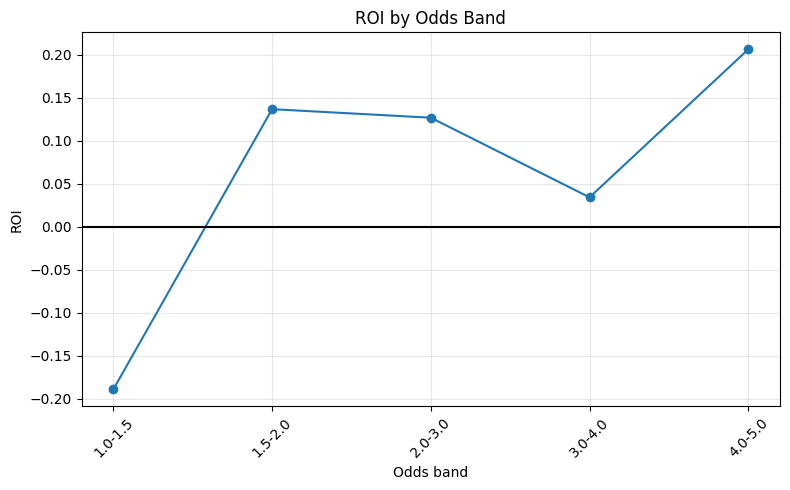

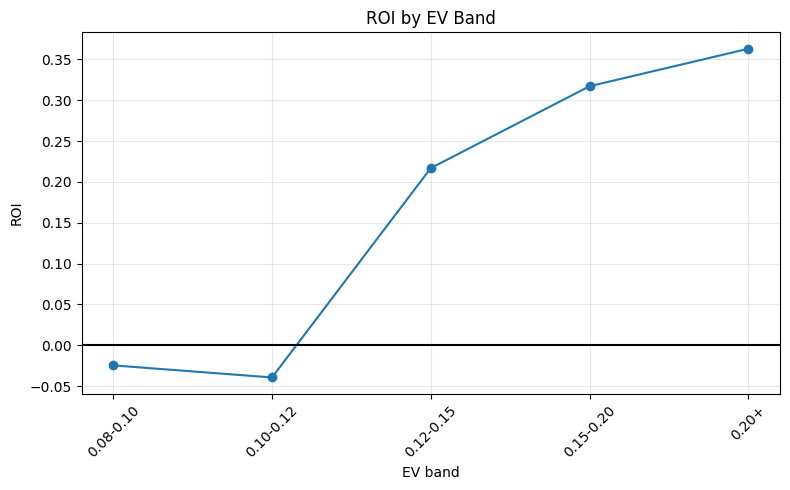

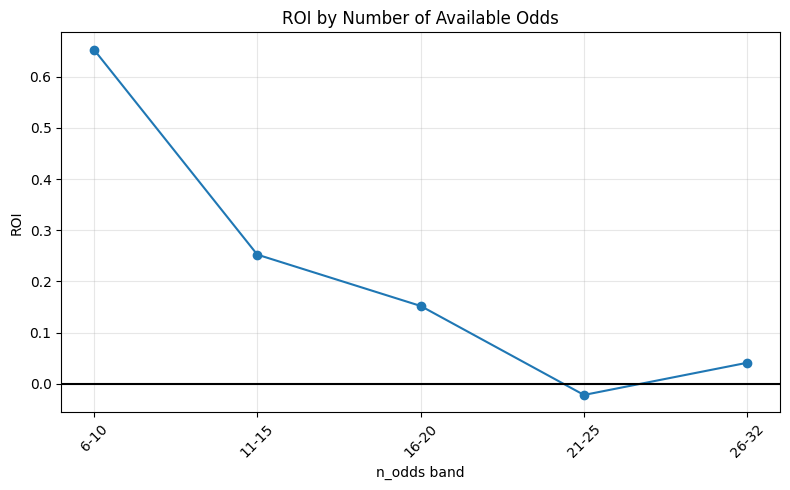

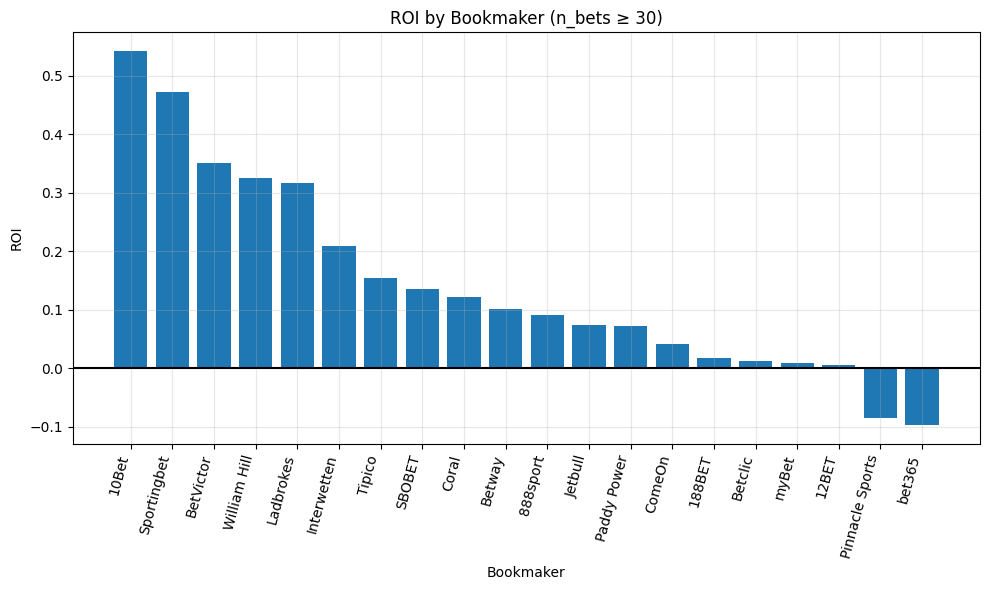

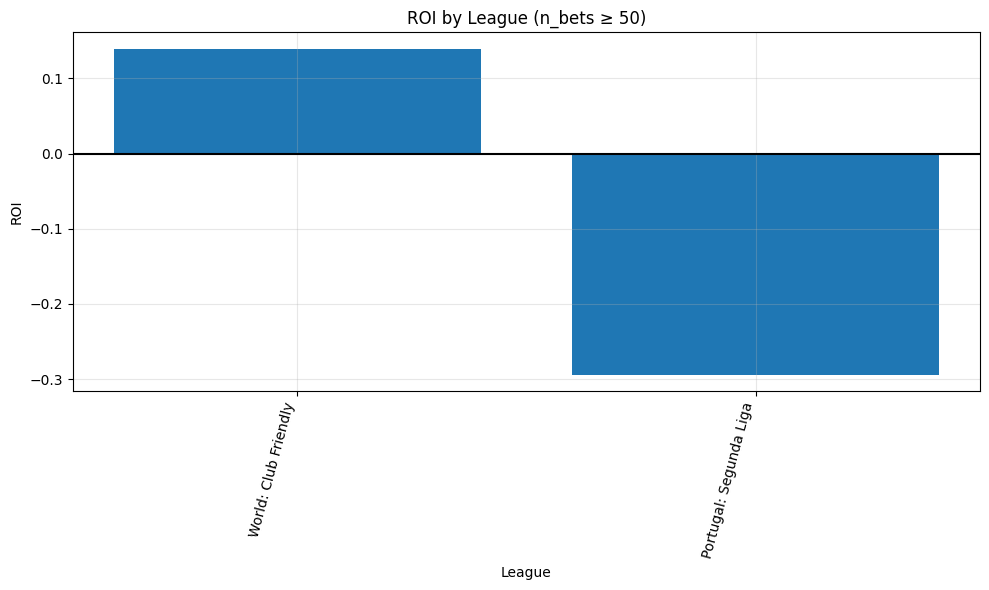

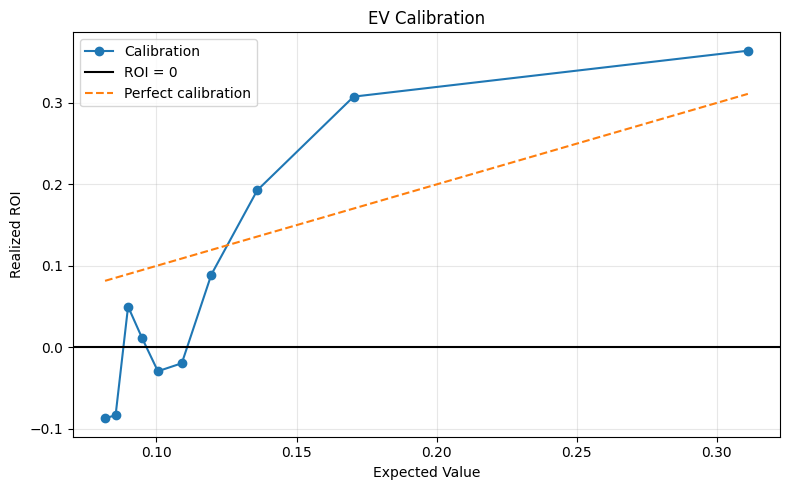

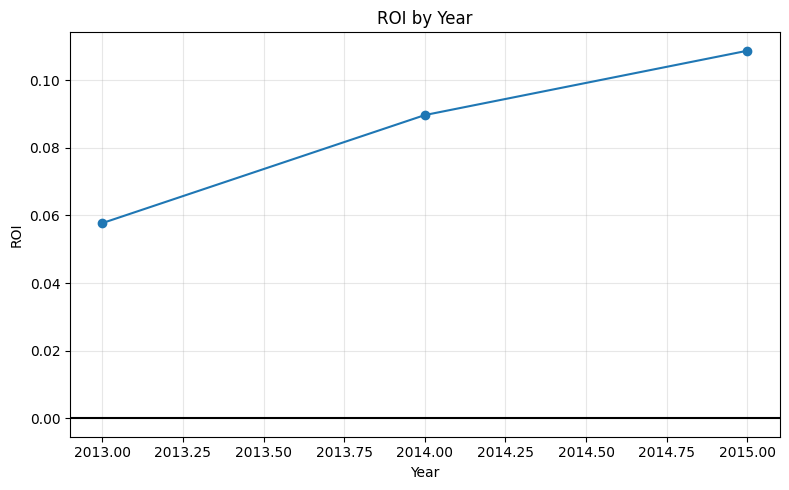

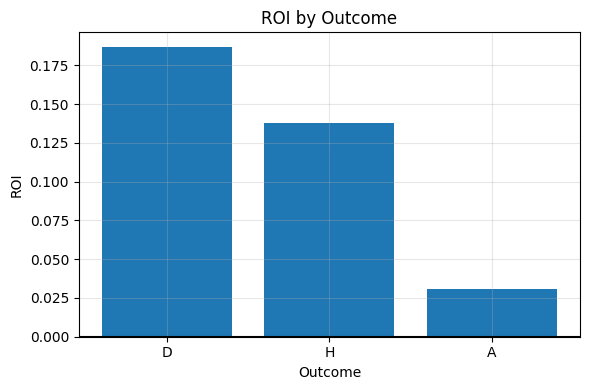

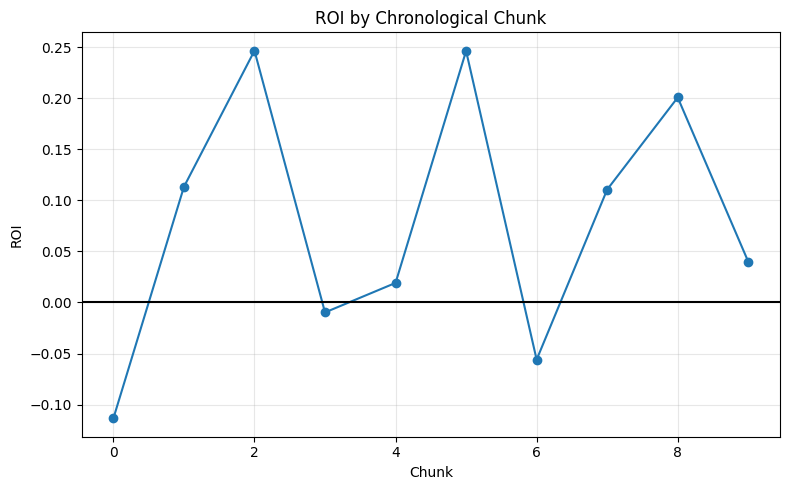

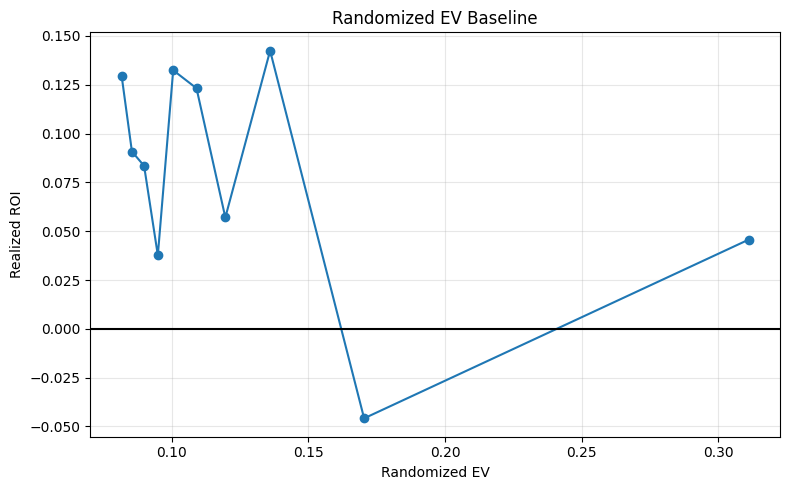

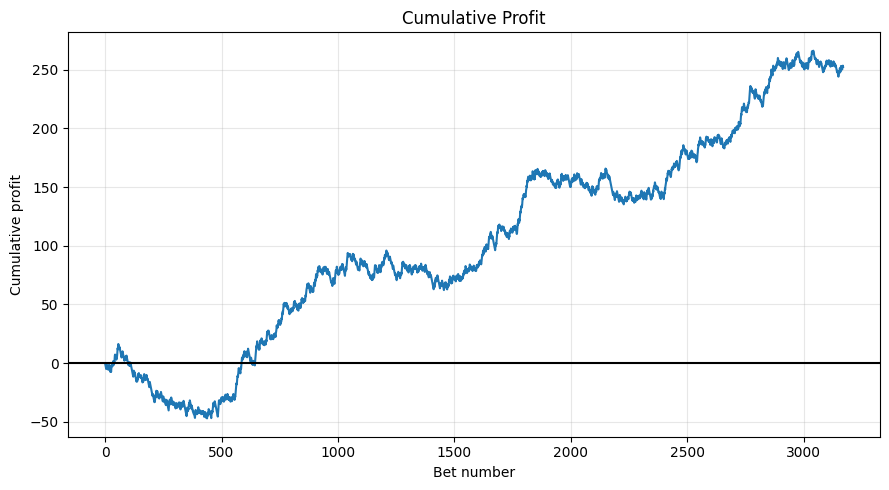

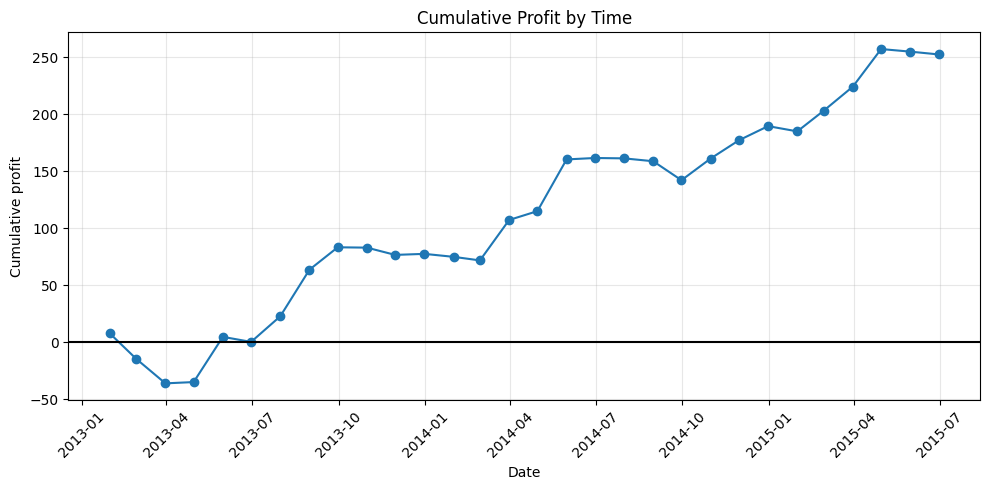

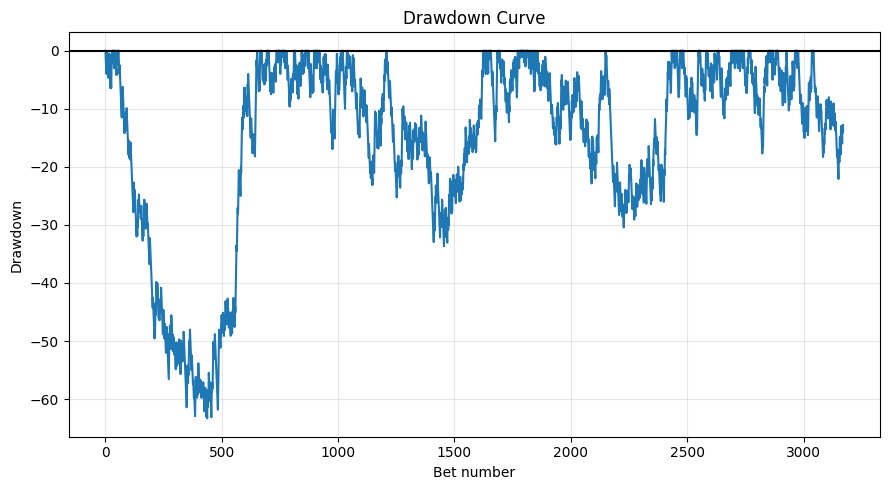

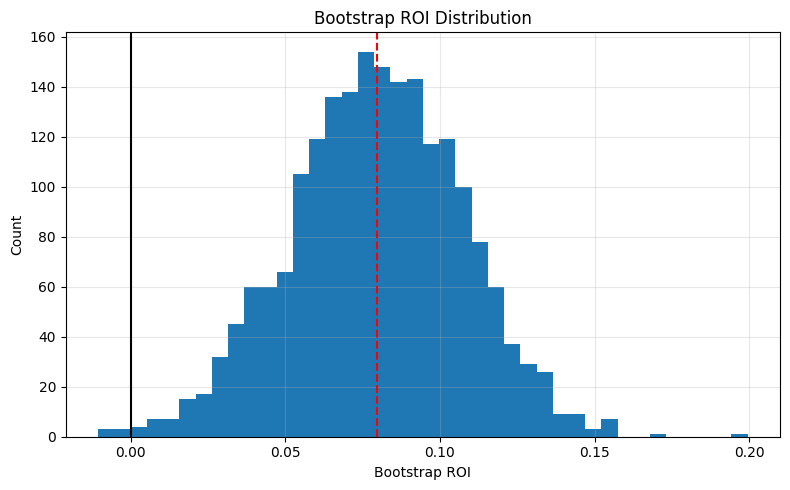

In [16]:
suite = run_diagnostic_suite(
    test_bets,
    bookmaker_min_bets=30,
    league_min_bets=50,
    chunk_count=10,
)

suite["summary_metrics"]
suite["odds_band"]
suite["ev_band"]
suite["bookmaker"]
suite["league"]
suite["ev_calibration"]
suite["yearly"]
suite["outcome_mix"]
suite["stability_chunks"]
suite["drawdown_stats"]
suite["bootstrap_stats"]

## Step 8 — Save selected outputs

This keeps the notebook aligned with the script-based workflow.

In [32]:
train_grid.to_csv(RESULTS_DIR / 'train_threshold_grid.csv', index=False)
test_tables['summary'].to_csv(RESULTS_DIR / 'test_summary.csv', index=False)
test_tables['by_year'].to_csv(RESULTS_DIR / 'test_by_year.csv', index=False)
test_tables['by_league'].to_csv(RESULTS_DIR / 'test_by_league.csv', index=False)
test_tables['by_outcome'].to_csv(RESULTS_DIR / 'test_by_outcome.csv', index=False)
test_tables['by_bookie'].to_csv(RESULTS_DIR / 'test_by_bookie.csv', index=False)
test_tables['by_n_odds_bin'].to_csv(RESULTS_DIR / 'test_by_n_odds_bin.csv', index=False)
test_bets.to_parquet(RESULTS_DIR / 'test_selected_bets.parquet', index=False)

print('Saved outputs to:', RESULTS_DIR)

Saved outputs to: c:\pl-pred\EPL-prediction\results\closing_backtest


## Next notebook section to add later

The natural next step is probability calibration:

1. Fit calibration on the training set
2. Apply calibrated probabilities to the test set
3. Recompute EV
4. Repeat the backtest

That should become the next notebook: `02_probability_calibration.ipynb`.